# SIM 1000s — Analysis

Simulations 1000–1008, 1109: hexagonal random foam compressed at 10 internal pressure levels
(1109 replaces 1009 — same pressure level, run for a longer duration).

Pressure series: `P = [0.0] + [0.004 × √2^i for i in 0..8]`

**Plots**
1. Reaction force vs displacement — all sims
2. Factor `f` (global efficiency tension / compression) vs displacement — all sims
3. Shear mean vs displacement — all sims
4. η_A (area-based) and η_C (aspect-ratio-based) localization indices vs displacement — all sims

In [1]:
import sys, os, pickle, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'
SIMS        = list(range(1000, 1009)) + [1109]


In [2]:
def load_pkl(path):
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_pressure(sim):
    path = os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0


In [3]:
PRESSURES = {sim: get_pressure(sim) for sim in SIMS}
print({sim: f'{p:.6f} MPa' for sim, p in PRESSURES.items()})


{1000: '0.000000 MPa', 1001: '0.040000 MPa', 1002: '0.056569 MPa', 1003: '0.080000 MPa', 1004: '0.113137 MPa', 1005: '0.160000 MPa', 1006: '0.226274 MPa', 1007: '0.320000 MPa', 1008: '0.452548 MPa', 1109: '0.640000 MPa'}


In [4]:
from matplotlib.lines import Line2D

# Manually picked from the interactive shear-mean-derivative plot (Plot 3b):
# LocalizationA = just before the first derivative jump, LocalizationB = just
# before the second. SIM 1109 has no LocalizationA (single-jump behaviour).
LOC_A = {1001: 2.12, 1002: 2.19, 1003: 2.29, 1004: 2.44, 1005: 2.62,
         1006: 2.93, 1007: 3.36, 1008: 3.99, 1109: 4.91}
LOC_B = {1001: 2.7, 1002: 2.79, 1003: 2.87, 1004: 2.99, 1005: 3.19,
         1006: 3.46, 1007: 3.83, 1008: 4.65}

def mark_localizations(ax, color, sim, displ, y):
    if sim in LOC_A:
        xA = LOC_A[sim]
        yA = np.interp(xA, displ, y)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=color, linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = LOC_B[sim]
        yB = np.interp(xB, displ, y)
        ax.scatter(xB, yB, marker='^', s=70, facecolor=color,
                   edgecolor='k', linewidths=0.8, zorder=5)

def add_localization_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    handles += [
        Line2D([], [], marker='v', linestyle='None', markerfacecolor='none', markeredgecolor='k', markersize=8),
        Line2D([], [], marker='^', linestyle='None', markerfacecolor='0.6', markeredgecolor='k', markersize=8),
    ]
    labels += ['Localization A', 'Localization B']
    return handles, labels


## Plot 1 — Reaction force vs displacement

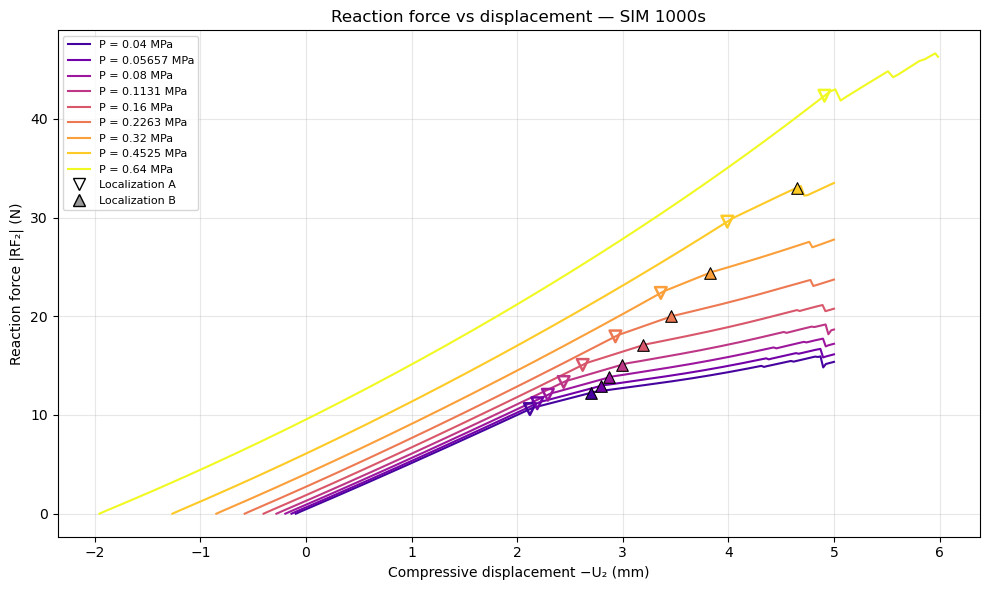

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    # U2 at PERN-9999997 is signed (positive = pressure-induced expansion in
    # Step-0, ramping down through 0 to the imposed compression in Step-1) and
    # is monotonically decreasing over time. Negate (don't abs!) to get a
    # monotonically increasing compressive-displacement axis.
    displ = -np.array(a2['U2']['PERN-9999997'])
    rf2   = np.abs(np.array(a2['RF2']['PERN-9999997']))
    del a2

    ax.plot(displ, rf2, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, rf2)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('Reaction force |RF₂| (N)')
ax.set_title('Reaction force vs displacement — SIM 1000s')
ax.legend(*add_localization_legend(ax), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2 — Factor `f` (tension / compression efficiency) vs displacement

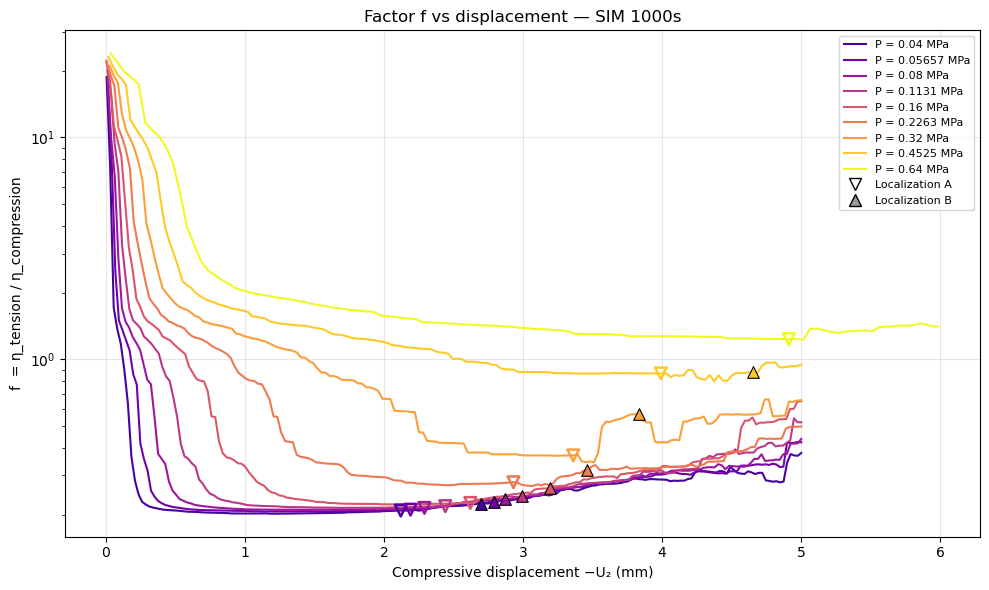

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    if a2 is None or i3 is None:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    mask = ~np.isnan(f) & (displ > 0)
    ax.plot(displ[mask], f[mask], color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ[mask], f[mask])

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('f  = η_tension / η_compression')
ax.set_title('Factor f vs displacement — SIM 1000s')
ax.set_yscale('log')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3 — Shear mean vs displacement

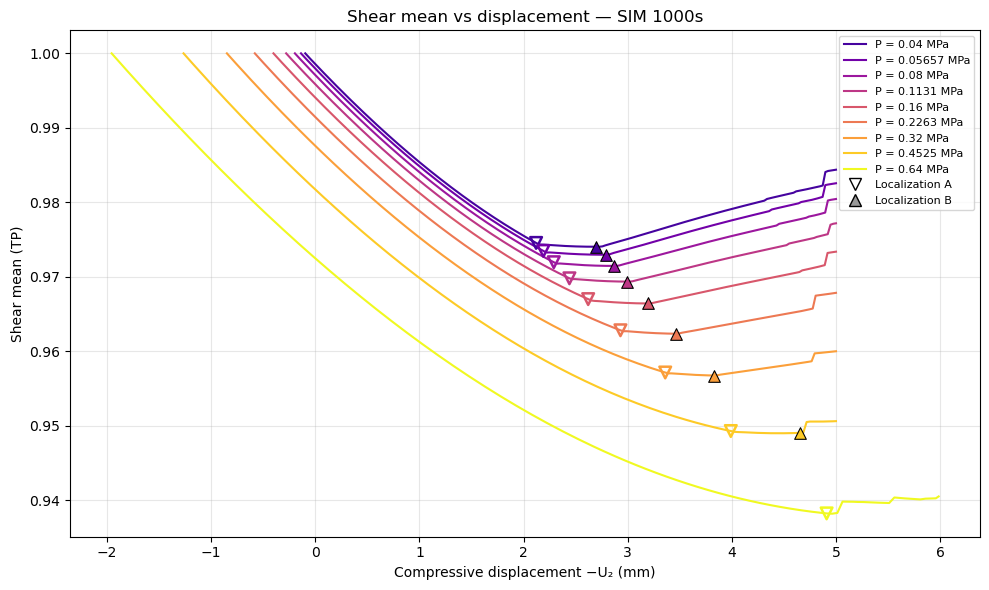

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    ax.plot(displ, shear_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, shear_mean)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('Shear mean (TP)')
ax.set_title('Shear mean vs displacement — SIM 1000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3b — d(Shear mean)/d(displacement) vs displacement

In [8]:
import plotly.graph_objects as go

fig = go.Figure()
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    dshear_dd = np.gradient(shear_mean, displ)
    r, g, b, _ = cmap(idx)
    color = f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'

    fig.add_trace(go.Scatter(
        x=displ, y=dshear_dd, mode='lines+markers',
        marker=dict(size=4), line=dict(color=color),
        name=f'SIM {sim} — P = {PRESSURES[sim]:.4g} MPa',
        hovertemplate='SIM %{text}<br>displ = %{x:.4f} mm<br>d(shear)/d(displ) = %{y:.5f}<extra></extra>',
        text=[str(sim)] * len(displ),
    ))

fig.update_layout(
    title='Shear mean derivative vs displacement — SIM 1000s (zoom/pan/hover to pick Localization A/B)',
    xaxis_title='Compressive displacement −U₂ (mm)',
    yaxis_title='d(Shear mean)/d(displacement) (TP/mm)',
    width=1000, height=650,
    hovermode='closest',
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()


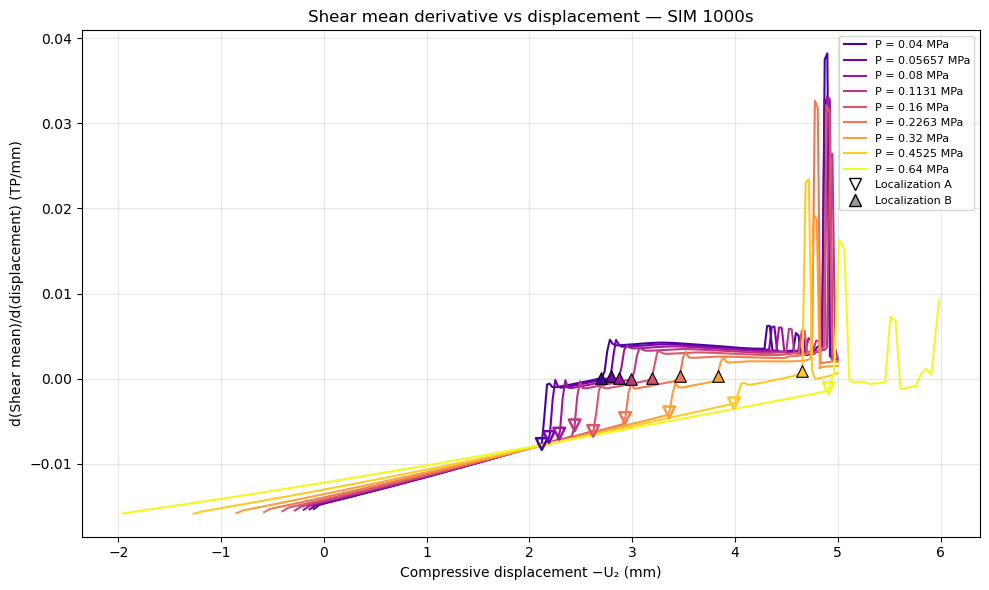

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    dshear_dd = np.gradient(shear_mean, displ)

    ax.plot(displ, dshear_dd, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, dshear_dd)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('d(Shear mean)/d(displacement) (TP/mm)')
ax.set_title('Shear mean derivative vs displacement — SIM 1000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 4 — $\eta_A$ (area-based) and $\eta_C$ (aspect-ratio-based) localization indices vs displacement

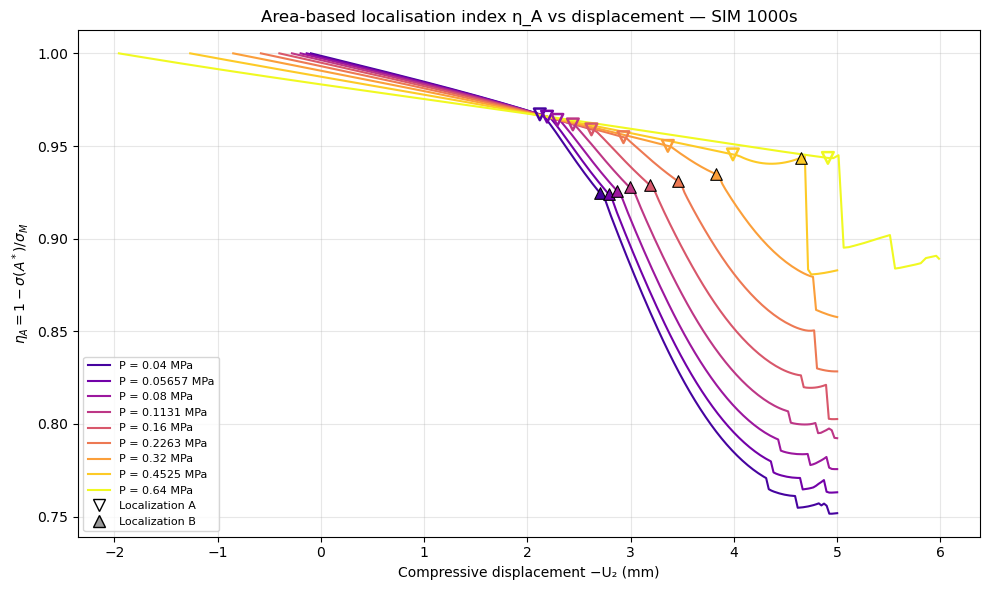

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
    if defc2 is None:
        continue
    # displacement here matches A2's U2 sign convention (signed, decreasing).
    displ  = -np.array(defc2['displacement'])
    eta_a  = np.array(defc2['etaC_A'])
    del defc2

    ax.plot(displ, eta_a, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, eta_a)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel(r'$\eta_A = 1 - \sigma(A^*)/\sigma_M$')
ax.set_title('Area-based localisation index η_A vs displacement — SIM 1000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


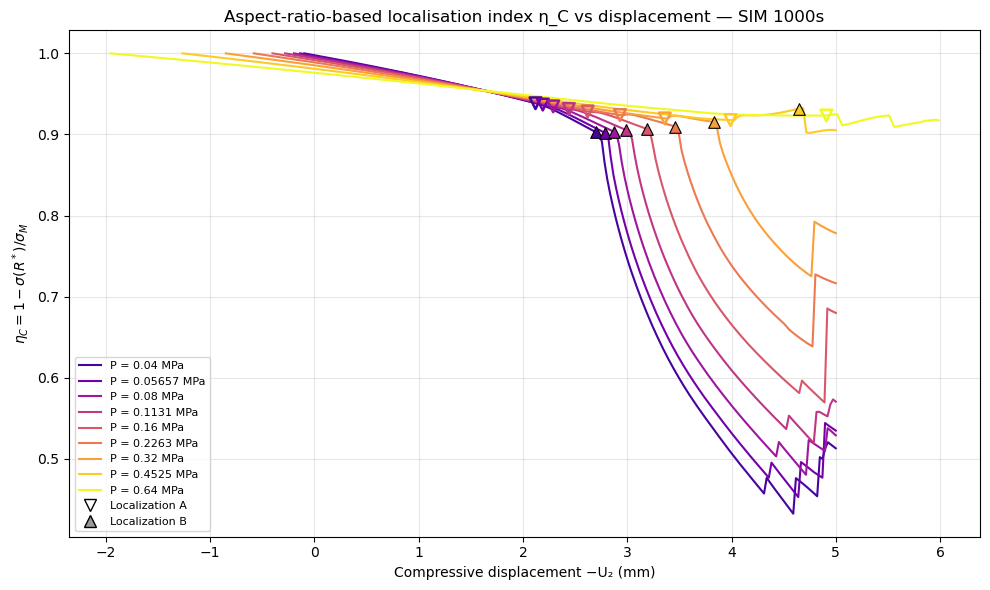

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
    if defc2 is None:
        continue
    displ  = -np.array(defc2['displacement'])
    eta_c  = np.array(defc2['etaC_R'])
    del defc2

    ax.plot(displ, eta_c, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, eta_c)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel(r'$\eta_C = 1 - \sigma(R^*)/\sigma_M$')
ax.set_title('Aspect-ratio-based localisation index η_C vs displacement — SIM 1000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 5 — Localization-point summary (factor f, displacement) vs internal pressure

In [12]:
loc_data = []
for sim in SIMS:
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    if a2 is None or i3 is None or sim not in PRESSURES:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    mask = ~np.isnan(f) & (displ > 0)
    displ_m, f_m = displ[mask], f[mask]

    # displ[0] is the displacement at t=0 (start of the simulation, before the
    # Step-0 pressure ramp), which is nonzero/negative in this signed
    # convention. Subtracting it gives the absolute compressive displacement
    # measured from the true start of the simulation.
    displ0 = displ[0]

    dispA = LOC_A.get(sim, np.nan)
    dispB = LOC_B.get(sim, np.nan)
    fA = np.interp(dispA, displ_m, f_m) if sim in LOC_A else np.nan
    fB = np.interp(dispB, displ_m, f_m) if sim in LOC_B else np.nan

    loc_data.append(dict(sim=sim, P=PRESSURES[sim], displ0=displ0,
                          dispA=dispA, dispA_abs=dispA - displ0, fA=fA,
                          dispB=dispB, dispB_abs=dispB - displ0, fB=fB))

loc_data.sort(key=lambda d: d['P'])
loc_data


[{'sim': 1001,
  'P': 0.04,
  'displ0': -0.09716366231441498,
  'dispA': 2.12,
  'dispA_abs': 2.217163662314415,
  'fA': 0.20845370389913243,
  'dispB': 2.7,
  'dispB_abs': 2.797163662314415,
  'fB': 0.22362358079859018},
 {'sim': 1002,
  'P': 0.05656854249492381,
  'displ0': -0.1380353569984436,
  'dispA': 2.19,
  'dispA_abs': 2.3280353569984436,
  'fA': 0.21035525755052462,
  'dispB': 2.79,
  'dispB_abs': 2.9280353569984436,
  'fB': 0.2285061377790775},
 {'sim': 1003,
  'P': 0.08000000000000002,
  'displ0': -0.19649748504161835,
  'dispA': 2.29,
  'dispA_abs': 2.4864974850416184,
  'fA': 0.21419775419407105,
  'dispB': 2.87,
  'dispB_abs': 3.0664974850416185,
  'fB': 0.23418890361934436},
 {'sim': 1004,
  'P': 0.11313708498984763,
  'displ0': -0.2805651128292084,
  'dispA': 2.44,
  'dispA_abs': 2.7205651128292083,
  'fA': 0.21820882591878632,
  'dispB': 2.99,
  'dispB_abs': 3.2705651128292086,
  'fB': 0.24136347501668734},
 {'sim': 1005,
  'P': 0.16000000000000003,
  'displ0': -0.402

### Plot 5a — Factor f at localization points vs internal pressure

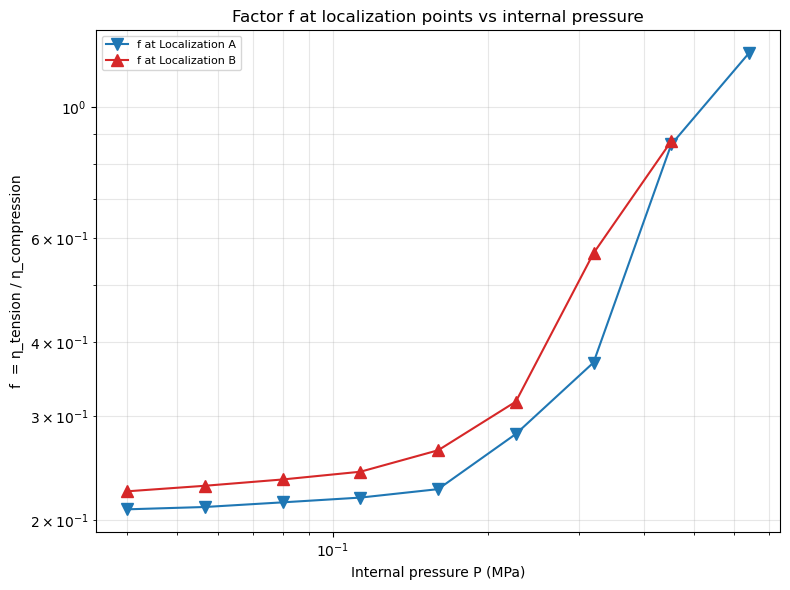

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

dA = [row for row in loc_data if np.isfinite(row['P']) and np.isfinite(row['fA'])]
dB = [row for row in loc_data if np.isfinite(row['P']) and np.isfinite(row['fB'])]

ax.plot([row['P'] for row in dA], [row['fA'] for row in dA], marker='v', ms=8,
        color='tab:blue', label='f at Localization A')
ax.plot([row['P'] for row in dB], [row['fB'] for row in dB], marker='^', ms=8,
        color='tab:red', label='f at Localization B')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Internal pressure P (MPa)')
ax.set_ylabel('f  = η_tension / η_compression')
ax.set_title('Factor f at localization points vs internal pressure')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()


### Plot 5b — Displacement at localization points vs internal pressure (raw and absolute)

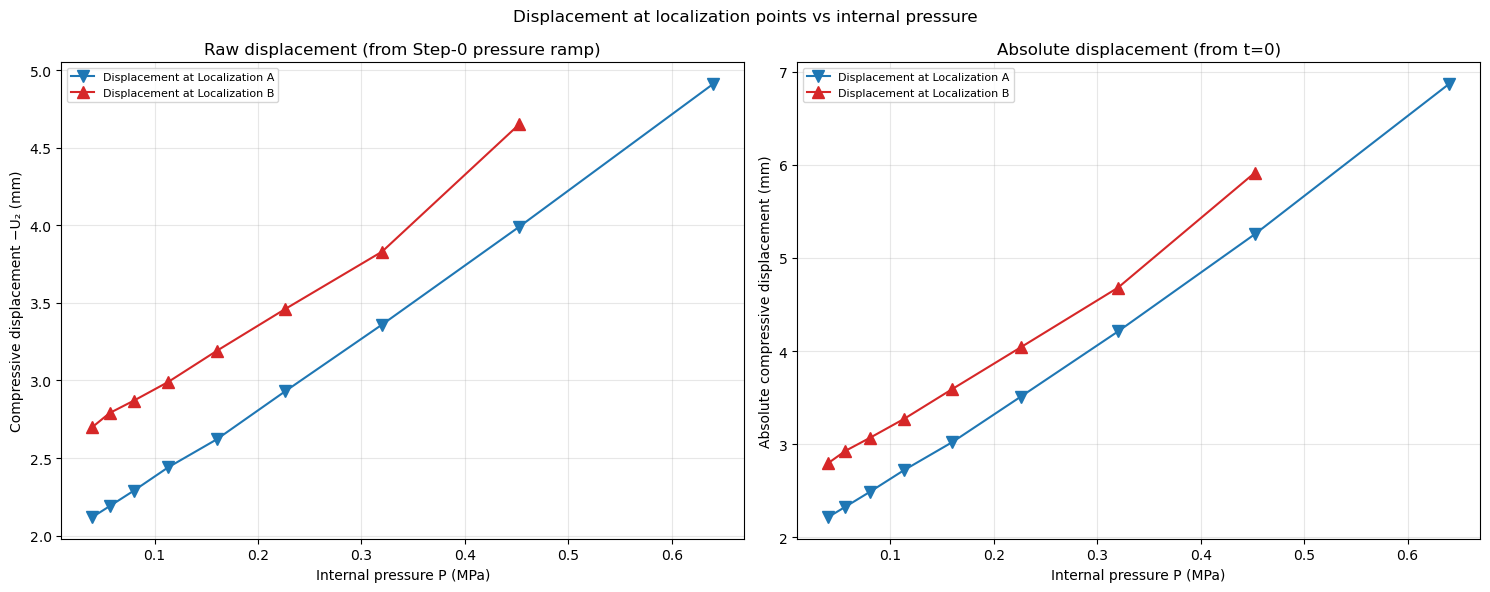

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

dA = [d for d in loc_data if not np.isnan(d['dispA'])]
dB = [d for d in loc_data if not np.isnan(d['dispB'])]

ax1.plot([d['P'] for d in dA], [d['dispA'] for d in dA], marker='v', ms=8,
         color='tab:blue', label='Displacement at Localization A')
ax1.plot([d['P'] for d in dB], [d['dispB'] for d in dB], marker='^', ms=8,
         color='tab:red', label='Displacement at Localization B')

ax1.set_xlabel('Internal pressure P (MPa)')
ax1.set_ylabel('Compressive displacement −U₂ (mm)')
ax1.set_title('Raw displacement (from Step-0 pressure ramp)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Absolute displacement: raw displacement minus displ(t=0), so every sim's
# displacement axis starts at 0 regardless of the pressure-induced expansion
# each one starts from.
ax2.plot([d['P'] for d in dA], [d['dispA_abs'] for d in dA], marker='v', ms=8,
         color='tab:blue', label='Displacement at Localization A')
ax2.plot([d['P'] for d in dB], [d['dispB_abs'] for d in dB], marker='^', ms=8,
         color='tab:red', label='Displacement at Localization B')

ax2.set_xlabel('Internal pressure P (MPa)')
ax2.set_ylabel('Absolute compressive displacement (mm)')
ax2.set_title('Absolute displacement (from t=0)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle('Displacement at localization points vs internal pressure')
fig.tight_layout()
plt.show()


### Plot 5c — Factor f at localization point vs displacement at localization point (raw and absolute)

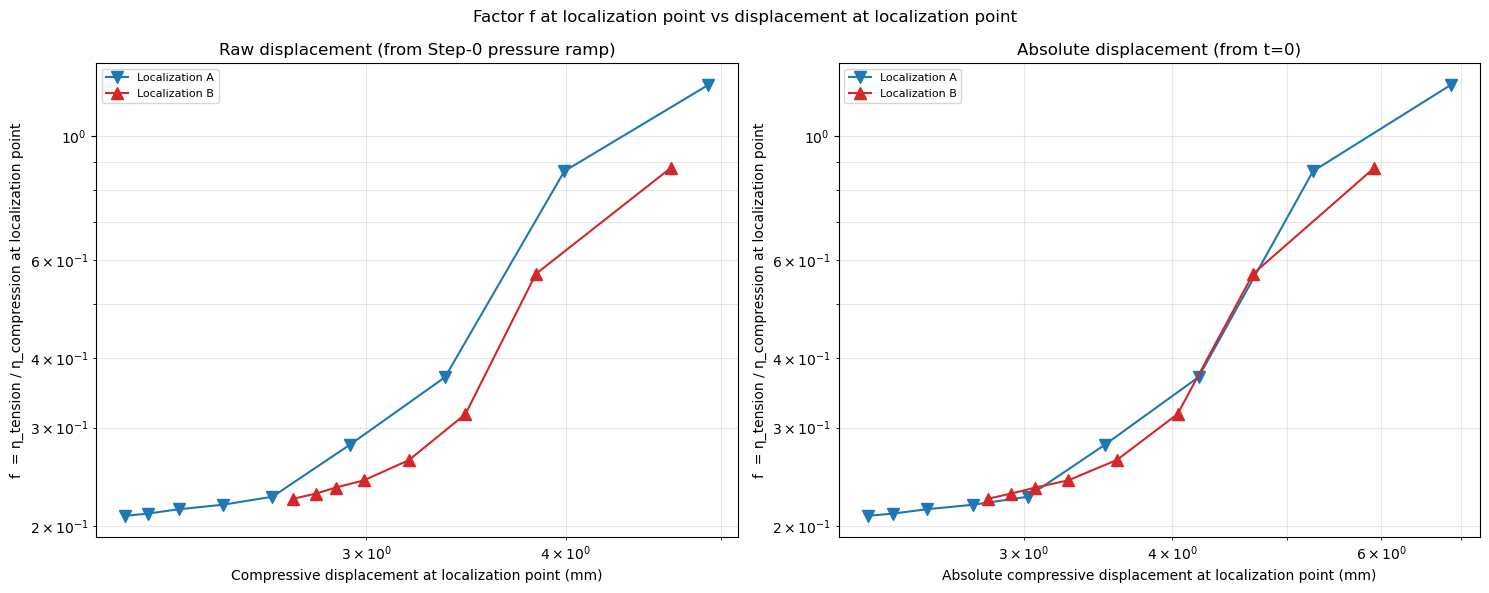

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

dA = [d for d in loc_data if not np.isnan(d['fA'])]
dB = [d for d in loc_data if not np.isnan(d['fB'])]

ax1.plot([d['dispA'] for d in dA], [d['fA'] for d in dA], marker='v', ms=8,
         color='tab:blue', label='Localization A')
ax1.plot([d['dispB'] for d in dB], [d['fB'] for d in dB], marker='^', ms=8,
         color='tab:red', label='Localization B')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Compressive displacement at localization point (mm)')
ax1.set_ylabel('f  = η_tension / η_compression at localization point')
ax1.set_title('Raw displacement (from Step-0 pressure ramp)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, which='both')

# Absolute displacement: raw displacement minus displ(t=0), so every sim's
# displacement axis starts at 0 regardless of the pressure-induced expansion
# each one starts from.
ax2.plot([d['dispA_abs'] for d in dA], [d['fA'] for d in dA], marker='v', ms=8,
         color='tab:blue', label='Localization A')
ax2.plot([d['dispB_abs'] for d in dB], [d['fB'] for d in dB], marker='^', ms=8,
         color='tab:red', label='Localization B')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Absolute compressive displacement at localization point (mm)')
ax2.set_ylabel('f  = η_tension / η_compression at localization point')
ax2.set_title('Absolute displacement (from t=0)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, which='both')

fig.suptitle('Factor f at localization point vs displacement at localization point')
fig.tight_layout()
plt.show()
